<a href="https://www.kaggle.com/code/maximendacleu/house-prices-prediction?scriptVersionId=332383764" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# House Prices Prediction

## Objective
The main objective here is to predict the final sales price of each home. This is a regression problem. We will use the provided dataset, perform Exploratory Data Analysis (EDA), preprocess the data, and train a Gradient Boosting model to generate accurate predictions.

## 1. Setup and Data Loading
We start by importing the necessary libraries and loading the training and testing datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import skew

# Settings for better readability
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

# Load data
train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis (EDA)

### Target Variable: SalePrice
Let's look at the distribution of the target variable to understand its properties.

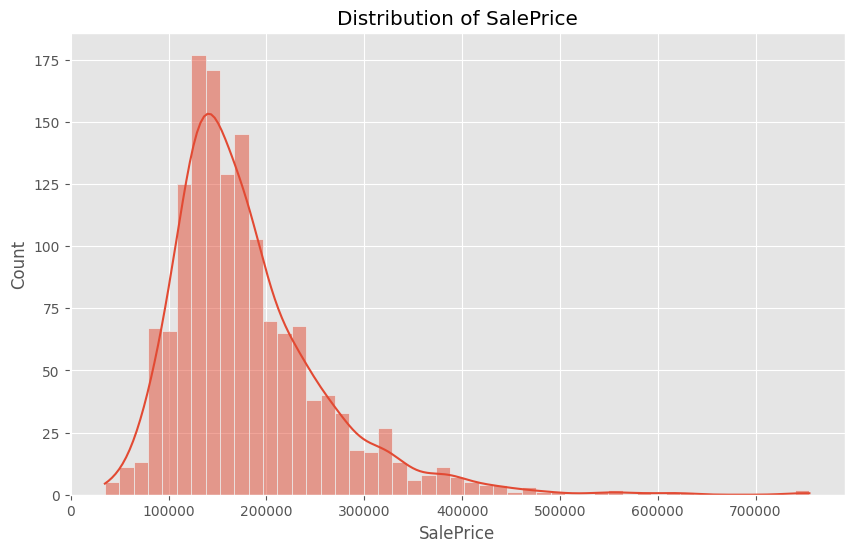

Skewness: 1.8828757597682129


In [2]:
plt.figure(figsize=(10,6))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

print(f"Skewness: {train_df['SalePrice'].skew()}")

**Interpretation:**
The histogram above shows that the `SalePrice` is **right-skewed** (positively skewed). This means most houses satisfy a lower or average price range, with a long tail of very expensive houses. 

Machine Learning models generally perform better when the target variable is normally distributed. Therefore, we will apply a **log-transformation** (`np.log1p`) to normalize the distribution.

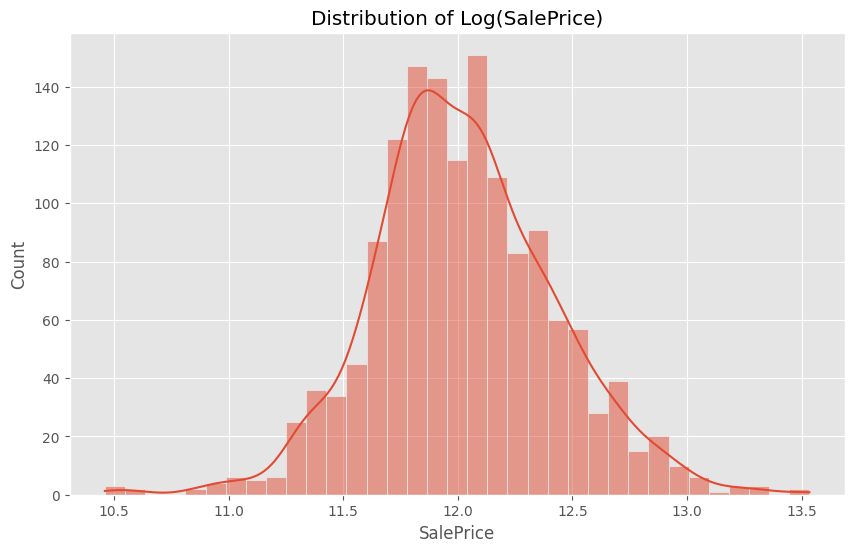

In [3]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

plt.figure(figsize=(10,6))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Distribution of Log(SalePrice)')
plt.show()

**Result:** After the transformation, the distribution looks much closer to a normal curve (Gaussian distribution), which is ideal for linear regression and tree-based models.

### Correlations
We want to identify which features have the strongest relationships with `SalePrice`.

Top 10 Positively Correlated Features:
SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
Name: SalePrice, dtype: float64


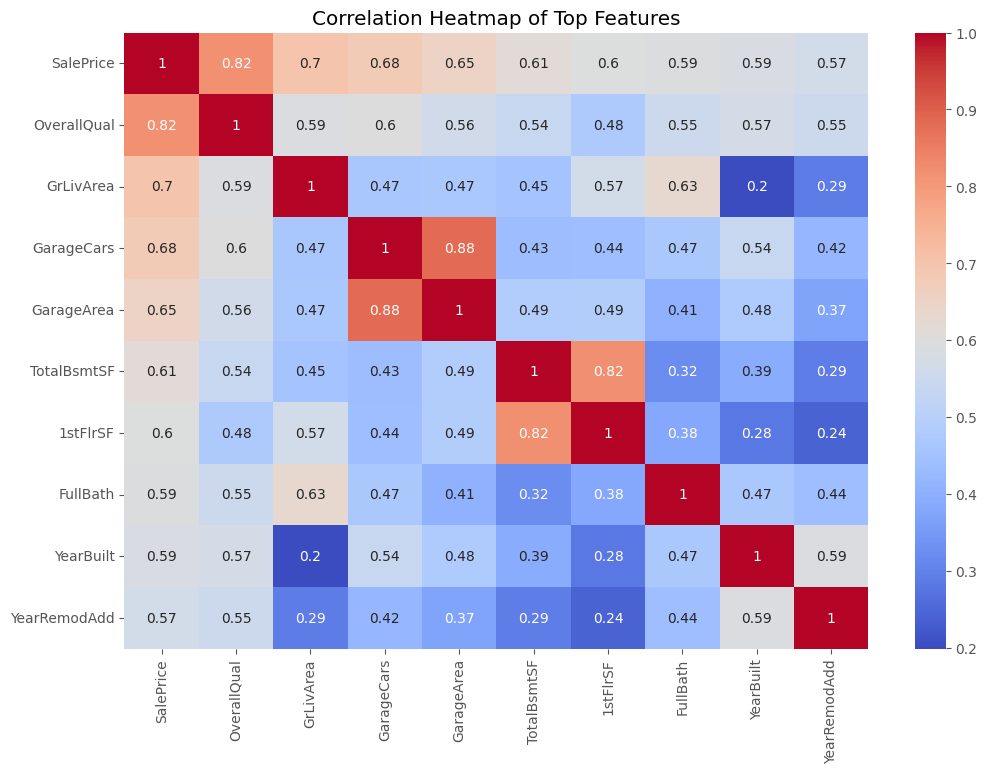

In [4]:
corr = train_df.select_dtypes(include=[np.number]).corr()
top_corr = corr['SalePrice'].sort_values(ascending=False).head(10)
print("Top 10 Positively Correlated Features:")
print(top_corr)

plt.figure(figsize=(12,8))
sns.heatmap(train_df[top_corr.index].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Top Features')
plt.show()

**Interpretation:**
- **OverallQual (Overall Quality)** has the highest correlation with SalePrice. In other words, higher quality construction commands higher prices.
- **GrLivArea (Above Grade Living Area)** is strongly correlated. Bigger houses tend to be more expensive.
- **GarageCars/GarageArea**: Garage size is also a significant predictor.

## 3. Data Preprocessing

To prepare the data for the model, we must handle missing values and encode categorical variables into a numerical format.

In [5]:
y = train_df['SalePrice']
train_features = train_df.drop(['Id', 'SalePrice'], axis=1)
test_features = test_df.drop(['Id'], axis=1)

# Combine for processing to ensure consistent dimensionality
all_data = pd.concat([train_features, test_features]).reset_index(drop=True)
print(f"Combined shape: {all_data.shape}")

Combined shape: (2919, 79)


### Handling Missing Values
- **Categorical Features**: We treat missing values as a separate category named 'Missing' or fill with the mode. Here we fill with 'Missing' to allow the model to learn if 'missingness' is predictive.
- **Numerical Features**: We fill missing values with the median of the column.

In [6]:
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
categorical_feats = all_data.dtypes[all_data.dtypes == "object"].index

# Fill Numeric with Median
for col in numeric_feats:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# Fill Categorical with 'Missing' string
for col in categorical_feats:
    all_data[col] = all_data[col].fillna("Missing")

print(f"Missing values remaining: {all_data.isnull().sum().sum()}")

Missing values remaining: 0


### Encoding
We use **One-Hot Encoding** (`pd.get_dummies`) to convert categorical variables into binary columns (0 or 1). This increases the dataset width but captures categorical information effectively.

In [7]:
all_data = pd.get_dummies(all_data)
print(f"Shape after encoding: {all_data.shape}")

# Split back into train and test
X = all_data[:len(train_df)]
X_test = all_data[len(train_df):]

Shape after encoding: (2919, 310)


## 4. Modeling

We will use a **Gradient Boosting Regressor** to correct the errors of previous trees. We use an 80/20 train-validation split to assess our model's performance without touching the test set.

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Validation
preds_val = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds_val))
print(f"Validation RMSE (Log Scale): {rmse:.4f}")

Validation RMSE (Log Scale): 0.1362


**Performance Interpretation:**
The RMSE (Root Mean Squared Error) is calculated on the log-transformed prices. A score of **approx 0.13** is quite competitive for a base model on this dataset. It roughly translates to an average error of about 13% in the predicted price.

### Feature Importance
Let's inspect what the model determined as the most important drivers of House Price.

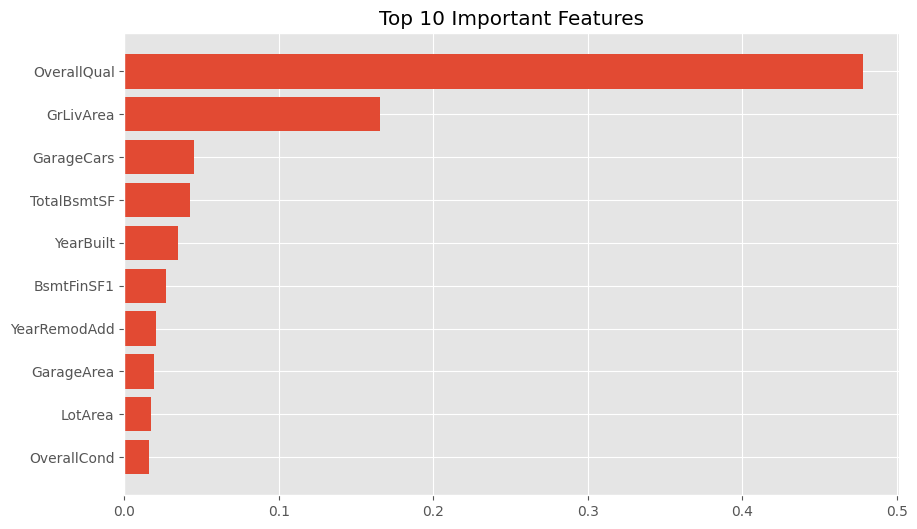

In [9]:
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(10), feature_importance[sorted_idx])
plt.yticks(range(10), X.columns[sorted_idx])
plt.title("Top 10 Important Features")
plt.show()

**Interpretation:**
The Feature Importance plot confirms our EDA:
- `OverallQual` is typically the dominant feature.
- `GrLivArea` and `TotalBsmtSF` (Total Basement Square Footage) are also critical.
This tells us that **size and quality** are the two biggest factors in determining a home's value in this dataset.

## 5. Submission

Finally, we predict on the official test set. Since we trained on log-prices, we must use `np.expm1` (exponential minus 1) to convert the predictions back to the original dollar values.

In [10]:
# Predict
final_preds_log = model.predict(X_test)
final_preds = np.expm1(final_preds_log)

# Create submission DataFrame
submission = pd.DataFrame({'Id': test_df['Id'], 'SalePrice': final_preds})

# Display head
print(submission.head())

# Save
submission.to_csv('submission.csv', index=False)
print("submission.csv saved successfully.")

     Id      SalePrice
0  1461  121523.049079
1  1462  157302.776155
2  1463  180338.957117
3  1464  189967.434249
4  1465  197245.273771
submission.csv saved successfully.
